# Netflix Data Analysis 

### Project Author: Poorav Sharma

## Project Objective

The objective of this project is to analyze Netflix Movies and TV Shows using Pandas and Matplotlib.

The analysis focuses on:
- Movies vs TV Shows
- Rating Distribution
- Movie Duration Analysis
- Release Year Trends
- Top 10 Countries
- Content Growth Over Time

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

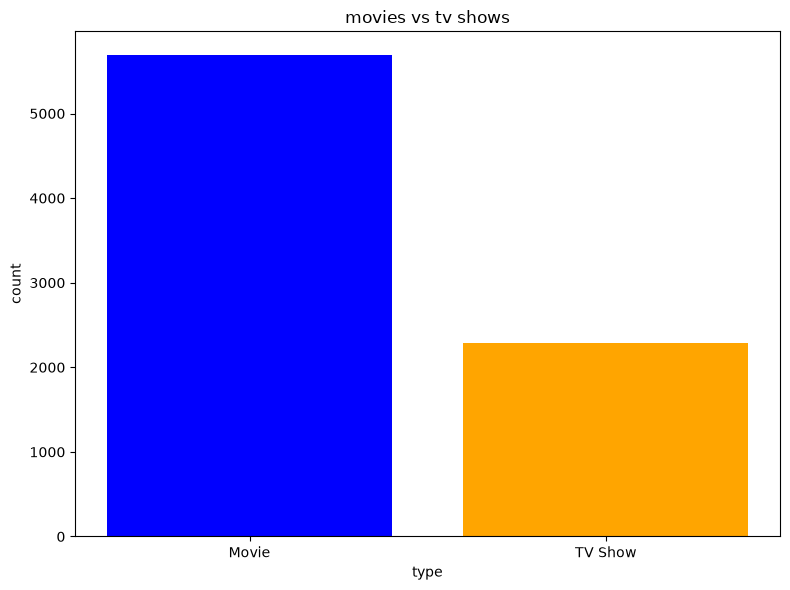

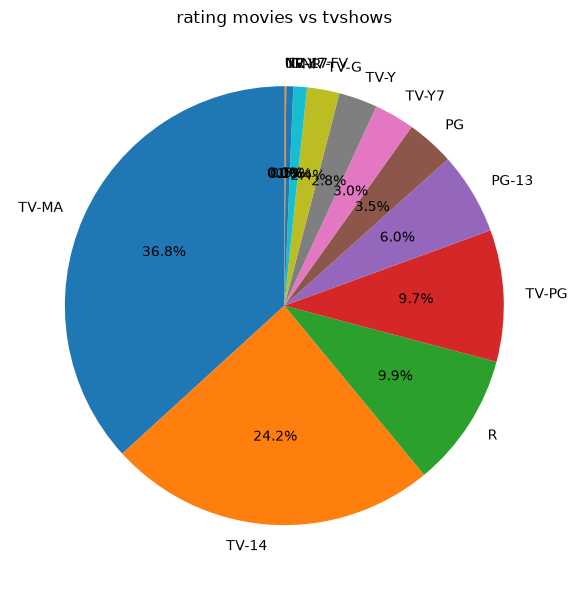

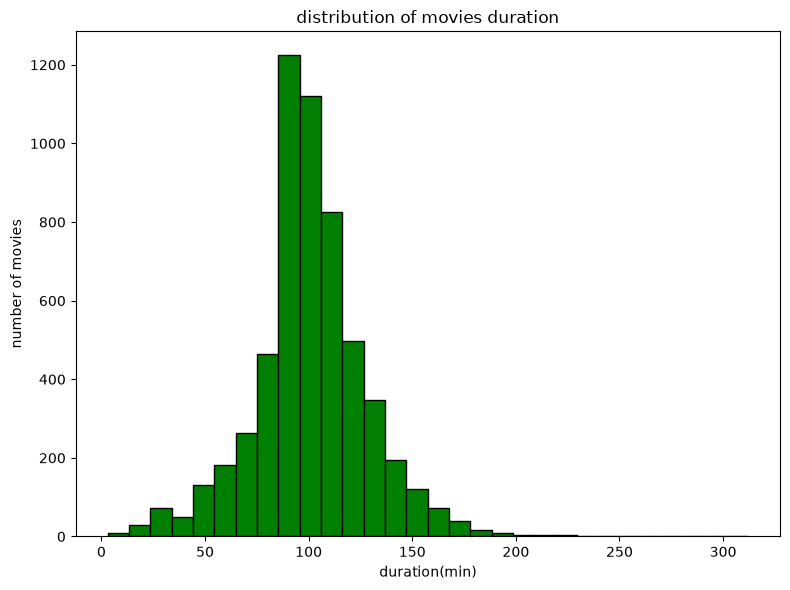

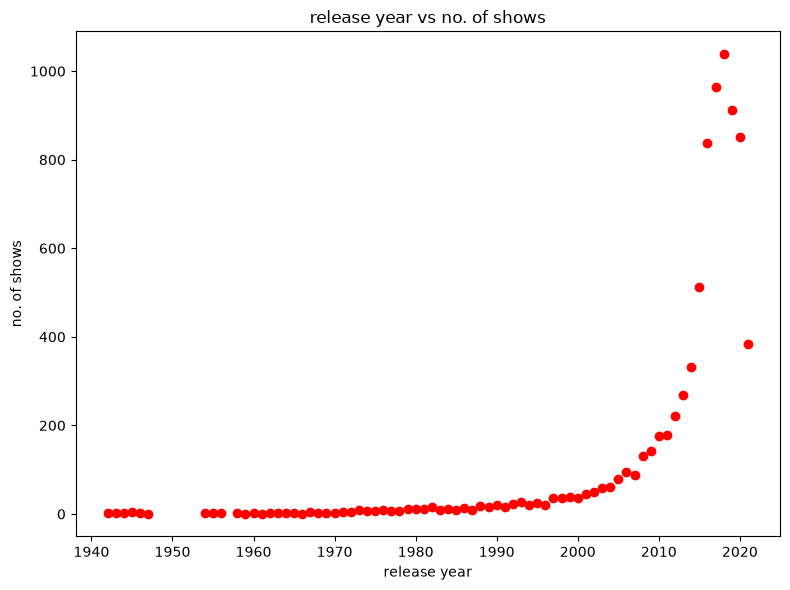

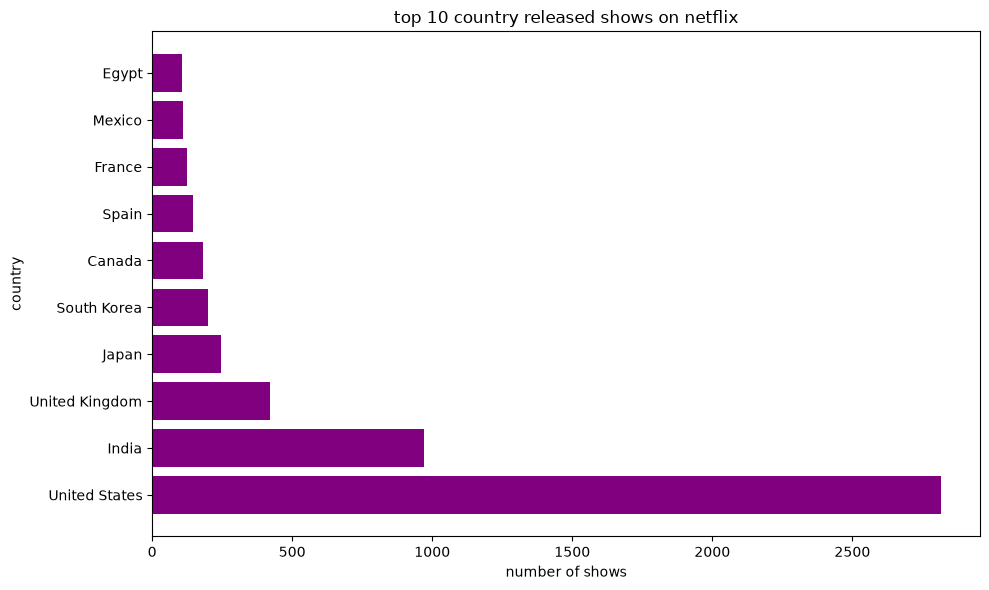

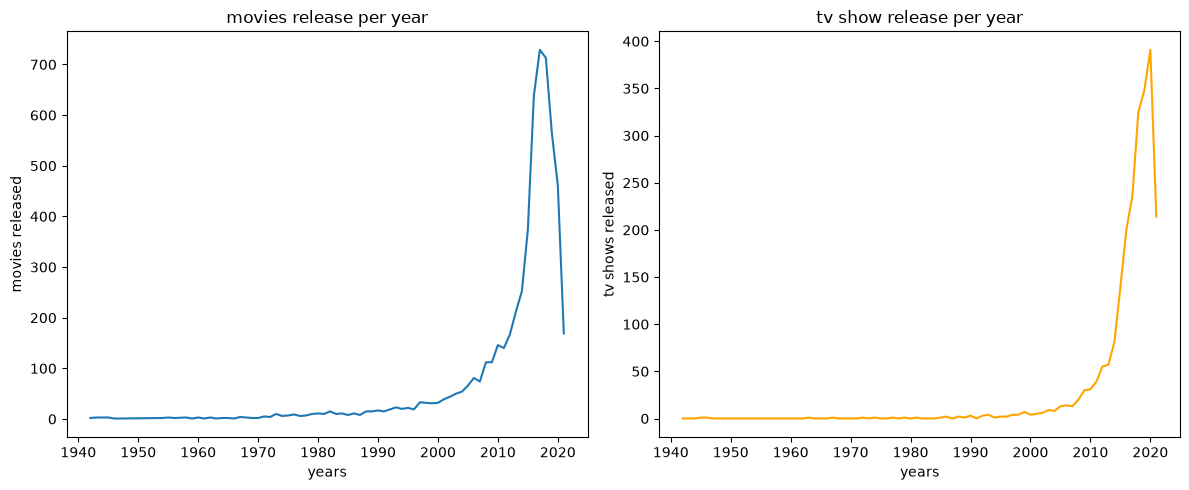

In [8]:
df = pd.read_csv('./data/netflix_titles.csv')

df = df.dropna(subset=['type' , 'country' , 'release_year' , 'rating' , 'duration'])


plt.figure(figsize=(8,6))
plt.bar(type_counts.index, type_counts.values, color=['blue', 'orange'])
plt.title('movies vs tv shows')
plt.xlabel('type')
plt.ylabel('count')
plt.tight_layout()
plt.savefig('./charts/movies_vs_tvshows.png')
plt.show()


rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index , autopct='%1.1f%%' , startangle=90)
plt.title('rating movies vs tvshows')
plt.tight_layout()
plt.savefig('./charts/rating_distribution.png')
plt.show()


movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_int'] = movies_df['duration'].str.replace(' min' , '').astype(int)

plt.figure(figsize=(8,6))
plt.hist(movies_df['duration_int'] , bins=30 , color='green' , edgecolor='black')
plt.title('distribution of movies duration')
plt.xlabel('duration(min)')
plt.ylabel('number of movies')
plt.tight_layout()
plt.savefig('./charts/movie_duration_distribution.png')
plt.show()

release_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(8,6))
plt.scatter(release_counts.index , release_counts.values , color='red')
plt.title('release year vs no. of shows')
plt.xlabel('release year')
plt.ylabel('no. of shows')
plt.tight_layout()
plt.savefig('./charts/release_year_trend.png')
plt.show()


country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.barh(country_counts.index, country_counts.values , color='purple')
plt.title('top 10 country released shows on netflix')
plt.xlabel('number of shows')
plt.ylabel('country')
plt.tight_layout()
plt.savefig('./charts/top_10_countries.png')
plt.show()

content_by_year = df.groupby(['release_year' , 'type']).size().unstack().fillna(0)

fig , ax = plt.subplots(1,2 , figsize=(12,5))

ax[0].plot(content_by_year.index , content_by_year['Movie'])
ax[0].set_title('movies release per year')
ax[0].set_xlabel('years')
ax[0].set_ylabel('movies released')

ax[1].plot(content_by_year.index , content_by_year['TV Show'] , color='orange')
ax[1].set_title('tv show release per year')
ax[1].set_xlabel('years')
ax[1].set_ylabel('tv shows released')
plt.tight_layout()
plt.savefig('./charts/movies_vs_tvshows_yearly.png')
plt.show()


# Key Insights

1. Movies dominate Netflix's content library.
2. Most content has been released in recent years.
3. A few countries contribute the majority of Netflix titles.
4. Movie durations are concentrated around common feature-film lengths.
5. Netflix has experienced significant content growth over time.